
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: K:\2026-09-15_14-22-37\Record Node 101\2026-09-15_14-22-37_experiment1_recording1_analysis

NI continuous (absolute): 106.659314 → 2664.499415 s
NP continuous (absolute): 106.649600 → 2664.482100 s

Canonical t0 = NP stream start = 106.649600 s (absolute)
NI stream starts +0.009714 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI TTL folder: K:\2026-09-15_14-22-37\Record Node 101\experiment1\recording1\events\NI-DAQmx-109.PXIe-6341\TTL
NP TTL folder: K:\2026-09-15_14-22-37\Record Node 101\experiment1\recording1\events\Neuropix-PXI-100.ProbeA-AP\TTL
NI sync pulses (bit 3): 2558
NP sync pulses (bit 0): 2558

Linear fit: t_NI = 0.999999999 * t_NP + -0.000000354
Residuals  mean=0.0000 ms  std=0.0191 ms  max=0.0538 ms

Saved alignment metadata.

Recording duration (canonical): 2557.832 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.009714 s
First 5 spi

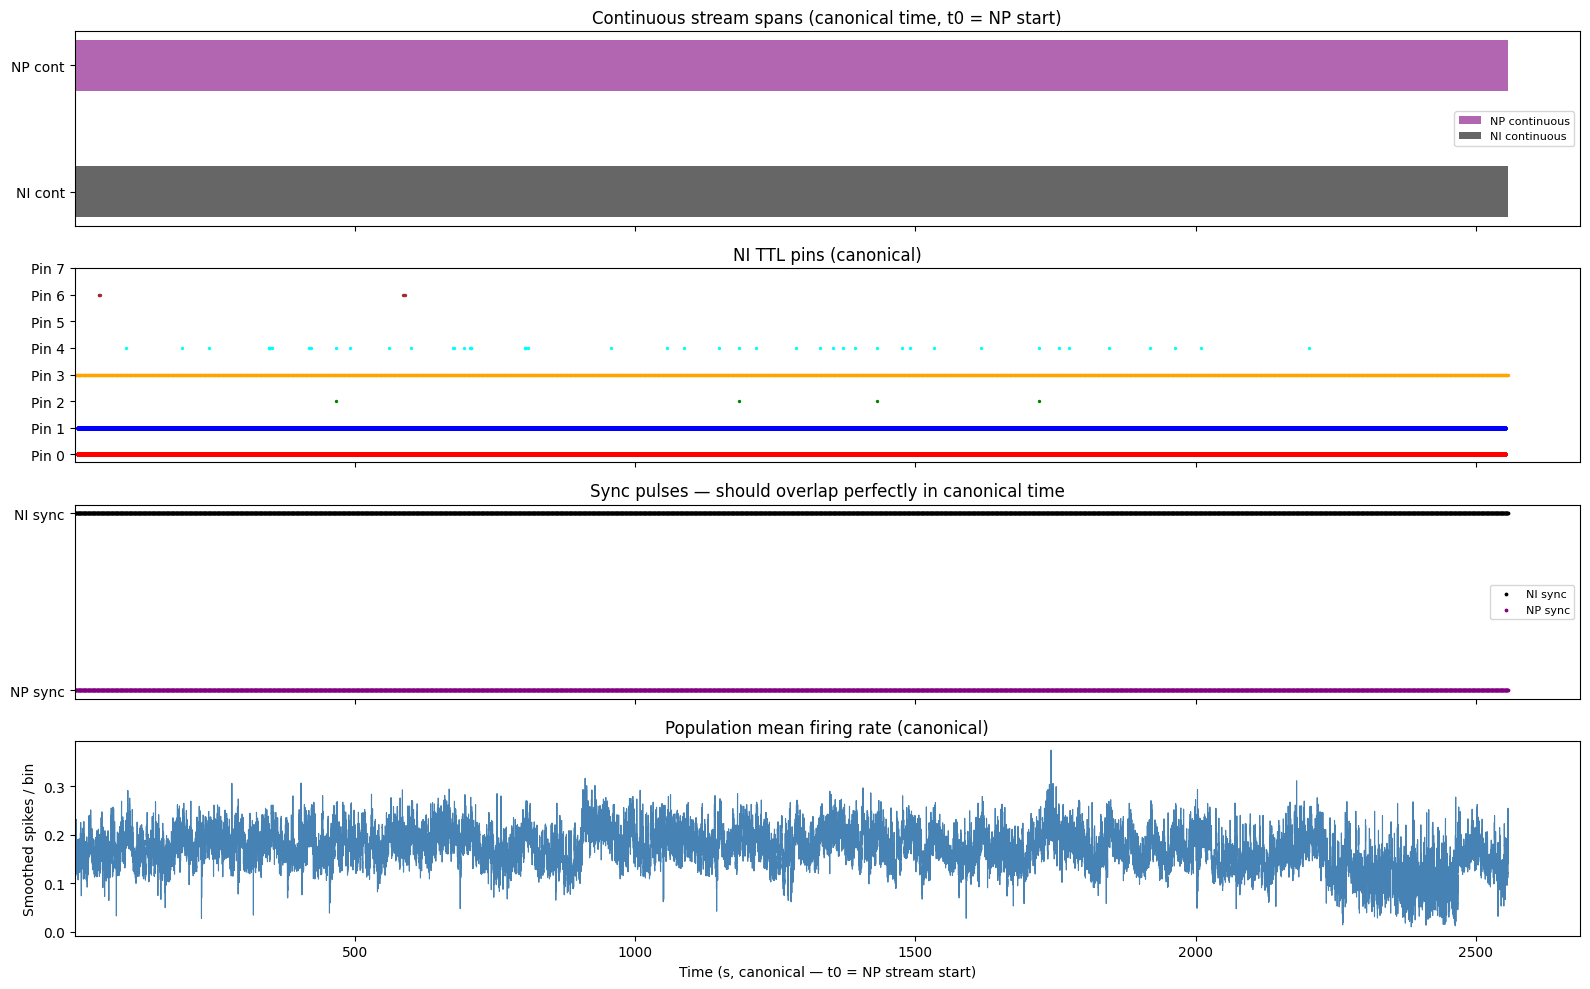

===== CELL A COMPLETE =====



In [1]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------


NI_TTL_FOLDER = r"K:\2026-09-15_14-22-37\Record Node 101\experiment1\recording1\events\NI-DAQmx-109.PXIe-6341\TTL"
PROBEA_PATH   = r"K:\2026-09-15_14-22-37\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA-AP\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 0
EXPECTED_RATE_HZ = 200
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 3
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

# Derive NP TTL folder from PROBEA_PATH, not hardcoded.
np_device_name    = probe_cont_folder.name                # Neuropix-PXI-XXX.ProbeA
np_recording_root = probe_cont_folder.parents[1]          # .../experimentN/recording1
np_ttl_folder     = np_recording_root / "events" / np_device_name / "TTL"

print(f"NI TTL folder: {ni_ttl_folder}")
print(f"NP TTL folder: {np_ttl_folder}")

if not np_ttl_folder.exists():
    raise FileNotFoundError(
        f"NP TTL folder not found:\n  {np_ttl_folder}\n"
        f"Check that PROBEA_PATH points to the correct kilosort4 folder."
    )

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

saved_block_idx = 0  # consecutive numbering for kept blocks
for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": saved_block_idx,
        "raw_block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{saved_block_idx}", block_times)
    print(f"  Block {saved_block_idx} (raw {b_idx}): {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")
    saved_block_idx += 1

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [3]:
# ============================================================
# CELL B — FRAME ALIGNMENT (FLIR/PySpin) — FINAL VERSION
# ============================================================
# Replaces the old Basler per-frame-file Cell B.
#
# FLIR acquisition produces per session folder:
#   {view}_counters.csv  — columns: counter, saved, host_ns, chunk_ts
#     counter  : camera hardware FrameID (free-running, NOT reset each session)
#     saved    : 1 if frame written to .raw file, 0 if dropped
#     host_ns  : PC clock time of retrieval (nanoseconds, for diagnostics only)
#     chunk_ts : camera internal hardware timestamp (nanoseconds, ~5ns res)
#
# Alignment method:
#   - Cell A detected N rising edges on CAMERA_TTL_PIN → N trigger pulses
#   - TTL block i has ttl_times_block[i] = canonical time of trigger i
#   - counter[row] - counter[0] = trigger index within the block
#   - saved frames (saved==1) get canonical_time = ttl_times_block[trigger_index]
#   - dropped frames (saved==0) are excluded; their trigger slots just have no frame
#
# Outputs to analysis_folder/camera_alignment/:
#   frame_canonical_times_block{N}.npy  — canonical time for each SAVED frame
#   frame_cnt_block{N}.npy              — trigger index for each saved frame
#   ttl_times_block{N}.npy              — full TTL block (already saved by Cell A,
#                                         but Cell C needs the path — see note)
#
# Outputs to analysis_folder/metadata/:
#   frame_alignment.json  — per-block summary Cell C reads
#
# REQUIREMENTS:
#   - Run Cell A first (provides analysis_folder, ttl_blocks, block_info)
#   - Counters CSV must be accessible from this machine
#   - analysis_folder must be accessible (same machine or network share)
#
# PORTABLE AFTER THIS CELL:
#   Everything from Cell C onward only needs analysis_folder.
# ============================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (FLIR) =====")

required_vars = ["analysis_folder", "ttl_blocks", "block_info"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ============================================================
# USER EDIT — one entry per CAMERA TTL block
# ============================================================
# Map block_index → (counters_csv_path, camera_view_name)
# Block 0 is usually the short pre-session block — if you didn't
# record camera data for it, set its csv to None to skip alignment.
# Cell C will still have a session entry for it (0 frames).
#
# For freely moving sessions there is typically one real block (block 1).
# block_index matches what Cell A called them (0-indexed by TTL gaps).

CAMERA_BLOCKS = {
    0: (r"C:\Users\Shermanlab\Downloads\15092026-1_paw_angled_counters.csv",  "paw_angled"),
}
# ============================================================

cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)
metadata_dir  = analysis_folder / "metadata"
metadata_dir.mkdir(exist_ok=True)

# Validate block count
n_blocks = len(ttl_blocks)
if set(CAMERA_BLOCKS.keys()) != set(range(n_blocks)):
    raise ValueError(
        f"CAMERA_BLOCKS keys must be {set(range(n_blocks))} "
        f"(one entry per TTL block, even if None). Got: {set(CAMERA_BLOCKS.keys())}"
    )

frame_alignment = {}   # filled per block, saved as frame_alignment.json

for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    n_ttls = len(ttl_times_block)
    print(f"  TTLs in block: {n_ttls}  "
          f"({ttl_times_block[0]:.3f} → {ttl_times_block[-1]:.3f} s canonical)")

    cfg = CAMERA_BLOCKS[block_index]

    # ── Skipped block ──────────────────────────────────────────────────────
    if cfg is None:
        print(f"  Skipping (no camera data for this block).")
        frame_alignment[str(block_index)] = {
            "skipped":       True,
            "n_ttls":        int(n_ttls),
            "n_saved_frames": 0,
            "note":          "No camera CSV provided — block skipped."
        }
        # Write stub arrays so Cell C paths don't crash
        stub = np.array([], dtype=np.int64)
        np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", stub)
        np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
                stub.astype(np.float64))
        continue

    # ── Real block ────────────────────────────────────────────────────────
    counters_csv, camera_view = cfg

    if not Path(counters_csv).exists():
        raise FileNotFoundError(
            f"Block {block_index}: counters CSV not found: {counters_csv}\n"
            f"If this machine doesn't have the camera data, copy the CSV "
            f"here or run Cell B on the camera PC."
        )

    print(f"  Camera view: {camera_view}")
    print(f"  Loading: {counters_csv}")

    df = pd.read_csv(counters_csv)

    # Validate columns
    required_cols = {"counter", "saved"}
    missing = required_cols - set(df.columns)
    if missing:
        raise RuntimeError(
            f"Block {block_index}: counters CSV missing columns: {missing}. "
            f"Found: {list(df.columns)}"
        )

    counter_arr = df["counter"].to_numpy(dtype=np.int64)
    saved_arr   = df["saved"].to_numpy(dtype=np.int64)

    n_rows      = len(df)
    n_saved     = int((saved_arr == 1).sum())
    n_dropped   = n_rows - n_saved
    first_ctr   = int(counter_arr[0])
    last_ctr    = int(counter_arr[-1])
    ctr_span    = last_ctr - first_ctr + 1   # total triggers received by camera

    print(f"  CSV rows:      {n_rows}")
    print(f"  Saved frames:  {n_saved}")
    print(f"  Dropped:       {n_dropped}  ({100*n_dropped/n_rows:.3f}%)")
    print(f"  Counter range: {first_ctr} → {last_ctr}  (span={ctr_span})")

    # ── Sanity: counter span vs TTL block ─────────────────────────────────
    if ctr_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: counter span ({ctr_span}) exceeds TTL count "
            f"({n_ttls}). Camera received more triggers than TTL detector found. "
            f"Check block boundaries in Cell A or that CAMERA_BLOCK_INDEX is correct."
        )

    trailing = n_ttls - ctr_span
    print(f"  Trailing TTLs (after camera stopped): {trailing}  "
          f"(~{ttl_times_block[-1] - ttl_times_block[ctr_span-1]:.2f} s)")
    if trailing > n_ttls * 0.10:
        print(f"  WARNING: >10% trailing TTLs — did the camera stop well "
              f"before OpenEphys? Check recording end times.")

    # ── Core mapping ──────────────────────────────────────────────────────
    # trigger_index[i] = which TTL pulse row i in the CSV corresponds to
    trigger_index = counter_arr - first_ctr   # shape (n_rows,)

    # Only keep saved frames
    saved_mask     = saved_arr == 1
    saved_triggers = trigger_index[saved_mask]   # shape (n_saved,)

    # Look up canonical times
    frame_canonical_times = ttl_times_block[saved_triggers]   # shape (n_saved,)

    # Validate: must be strictly increasing (guaranteed if counters are
    # monotone, but check anyway)
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: canonical times are not strictly increasing. "
            f"Counter values are non-monotone or there is a block mismatch."
        )

    # ── Interval QC ──────────────────────────────────────────────────────
    intervals_ms = np.diff(frame_canonical_times) * 1000.0
    mean_iv  = float(intervals_ms.mean())
    std_iv   = float(intervals_ms.std())
    min_iv   = float(intervals_ms.min())
    max_iv   = float(intervals_ms.max())
    print(f"\n  Frame interval stats (saved frames):")
    print(f"    Mean: {mean_iv:.4f} ms  (expected 5.0000 ms at 200 Hz)")
    print(f"    Std:  {std_iv:.5f} ms")
    print(f"    Min:  {min_iv:.4f} ms    Max: {max_iv:.4f} ms")

    large_gaps = np.where(intervals_ms > 15.0)[0]  # >3× expected interval
    if len(large_gaps) == 0:
        print(f"    No large gaps — frame sequence is clean.")
    else:
        print(f"    Large gaps (>15ms): {len(large_gaps)}")
        for gi in large_gaps[:5]:
            print(f"      gap at saved-frame {gi}: {intervals_ms[gi]:.1f} ms")
        if len(large_gaps) > 5:
            print(f"      ... and {len(large_gaps)-5} more")

    # ── Save arrays ───────────────────────────────────────────────────────
    # These names match exactly what Cell C expects
    path_canonical = cam_align_dir / f"frame_canonical_times_block{block_index}.npy"
    path_cnt       = cam_align_dir / f"frame_cnt_block{block_index}.npy"

    np.save(path_canonical, frame_canonical_times)
    np.save(path_cnt,       saved_triggers)

    print(f"\n  Saved frame_canonical_times_block{block_index}.npy  "
          f"({n_saved} entries)")
    print(f"  Saved frame_cnt_block{block_index}.npy")
    print(f"  Canonical range: {frame_canonical_times[0]:.3f} → "
          f"{frame_canonical_times[-1]:.3f} s")

    # ── Also save per-view named files (QC / backward compat) ─────────────
    np.save(cam_align_dir / f"{camera_view}_frame_times.npy",
            frame_canonical_times)

    frame_alignment[str(block_index)] = {
        "skipped":          False,
        "camera_view":      camera_view,
        "counters_csv":     str(counters_csv),
        "n_ttls":           int(n_ttls),
        "n_saved_frames":   n_saved,
        "n_dropped_frames": n_dropped,
        "loss_rate_pct":    round(100.0 * n_dropped / n_rows, 4),
        "first_counter":    int(first_ctr),
        "last_counter":     int(last_ctr),
        "frame_time_range_s": [
            float(frame_canonical_times[0]),
            float(frame_canonical_times[-1])
        ],
        "mean_interval_ms": round(mean_iv, 4),
        "std_interval_ms":  round(std_iv, 5),
    }

# ── Save frame_alignment.json ─────────────────────────────────────────────
fa_path = metadata_dir / "frame_alignment.json"
with open(fa_path, "w") as f:
    json.dump(frame_alignment, f, indent=2)
print(f"\nSaved frame_alignment.json → {fa_path}")

print("\n===== CELL B COMPLETE =====")
print("Pipeline is now portable from Cell C onward.")
print("Copy analysis_folder to any machine to continue.\n")


===== CELL B — FRAME ALIGNMENT (FLIR) =====

--- Block 0 ---
  TTLs in block: 509465  (6.183 → 2551.941 s canonical)
  Camera view: paw_angled
  Loading: C:\Users\Shermanlab\Downloads\15092026-1_paw_angled_counters.csv
  CSV rows:      509464
  Saved frames:  509464
  Dropped:       0  (0.000%)
  Counter range: 2180605 → 2690068  (span=509464)
  Trailing TTLs (after camera stopped): 1  (~0.00 s)

  Frame interval stats (saved frames):
    Mean: 4.9969 ms  (expected 5.0000 ms at 200 Hz)
    Std:  0.00896 ms
    Min:  4.9156 ms    Max: 5.0328 ms
    No large gaps — frame sequence is clean.

  Saved frame_canonical_times_block0.npy  (509464 entries)
  Saved frame_cnt_block0.npy
  Canonical range: 6.183 → 2551.936 s

Saved frame_alignment.json → K:\2026-09-15_14-22-37\Record Node 101\2026-09-15_14-22-37_experiment1_recording1_analysis\metadata\frame_alignment.json

===== CELL B COMPLETE =====
Pipeline is now portable from Cell C onward.
Copy analysis_folder to any machine to continue.



In [5]:
# ============================================================
# CELL C — SESSION BUILDER (PORTABLE)
# ============================================================
# First cell after the rig/home line. Defines DLC paths and
# writes session.json with all metadata needed for downstream
# analysis. Loads ttl_blocks etc. from disk if not in kernel.
# ============================================================
import os, json
import numpy as np
from pathlib import Path

print("\n===== CELL C — SESSION BUILDER (PORTABLE) =====")

# ------------------------------------------------------------
# USER EDIT — set analysis_folder
# ------------------------------------------------------------
analysis_folder = Path(r"K:\2026-09-15_14-22-37\Record Node 101\2026-09-15_14-22-37_experiment1_recording1_analysis"
)
# ------------------------------------------------------------

analysis_folder = Path(analysis_folder)

# ------------------------------------------------------------
# USER EDIT — DLC outputs
# ------------------------------------------------------------
# Block 0 was skipped (no camera data). Block 1 is the main session.
# Set bottom_cam DLC path here when that model is trained and run.
# For now only paw_angled is available.
DLC_OUTPUTS = {
    0: r"C:\Users\Shermanlab\Desktop\4103-Kevin-2026-09-22\videos\15092026-1_paw_angledDLC_Resnet50_4103Sep22shuffle2_snapshot_best-100.h5",
}

# Set True to skip DLC file existence check (use if .h5 is not
# accessible from this machine right now — session.json will still
# be written, but Cell D will fail if paths are wrong).
SKIP_DLC_CHECK = False
# ------------------------------------------------------------

# Pin labels — correctly mapped for freely moving rig v12
# NI DAQ channel assignments verified Sept 22 2026
PIN_LABELS = {
    0: "paw_cam_trigger",       # Camera Arduino pin 5 → 200Hz TTL
    1: "bottom_cam_trigger",    # Camera Arduino pin 9 → 200Hz TTL
    2: "opto_led",              # Behavioral Arduino pin 11 → Thorlabs LED
    3: "sync_1hz",              # IMEC PXIe 1Hz master sync pulse
    4: "back_beam",             # Trial start: mouse enters rear of chamber
    5: "unused",
    6: "pellet_beam",           # Reach detected: paw at pellet position
    7: "reach_port_ttl",        # Reach port (eliminated from logic, may fire)
}
CAMERA_TTL_PIN = 0              # Paw cam trigger is on NI DAQ ch 0

# ------------------------------------------------------------
# LOAD CELL A METADATA FROM DISK
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
with open(analysis_folder / "metadata" / "block_info.json") as f:
    block_info = json.load(f)
with open(analysis_folder / "metadata" / "frame_alignment.json") as f:
    frame_meta = json.load(f)

# ------------------------------------------------------------
# RELOAD ttl_blocks AND all_pin_ttls FROM DISK IF NEEDED
# ------------------------------------------------------------
cam_align_dir = analysis_folder / "camera_alignment"
ttls_dir = analysis_folder / "ttls"

ttl_blocks = []
for bi in block_info:
    idx = bi["block_index"]
    ttl_blocks.append(np.load(cam_align_dir / f"ttl_times_block{idx}.npy"))

all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# Report what we have on each pin
print("\nTTL pin summary:")
for pin, times in all_pin_ttls.items():
    label = PIN_LABELS.get(pin, f"pin {pin}")
    if len(times) > 0:
        print(f"  Pin {pin} ({label}): {len(times)} events  "
              f"({times[0]:.2f} → {times[-1]:.2f} s)")
    else:
        print(f"  Pin {pin} ({label}): no events")

# ------------------------------------------------------------
# VALIDATE DLC MAPPING
# ------------------------------------------------------------
# Only real (non-skipped) blocks need DLC
real_blocks = [bi["block_index"] for bi in block_info
               if not frame_meta.get(str(bi["block_index"]), {}).get("skipped", False)]

if set(DLC_OUTPUTS.keys()) != set(real_blocks):
    raise ValueError(
        f"DLC_OUTPUTS keys {set(DLC_OUTPUTS.keys())} must match "
        f"real (non-skipped) block indices {set(real_blocks)}."
    )

if not SKIP_DLC_CHECK:
    for b, path in DLC_OUTPUTS.items():
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"DLC file for block {b} not found: {path}\n"
                f"Set SKIP_DLC_CHECK = True to bypass and write session.json anyway."
            )
        else:
            print(f"\nDLC block {b}: found {Path(path).name}")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {
    "canonical_t0_abs":         align_meta["t0_abs"],
    "canonical_t0_description": "NP stream start (absolute OpenEphys clock seconds)",
    "recording_duration_s":     ttl_meta["recording_duration"],
    "spike_anchor_offset_s":    ttl_meta["spike_anchor_offset_s"],
    "np_to_ni_a":               align_meta["np_to_ni_a"],
    "np_to_ni_b":               align_meta["np_to_ni_b"],
    "camera_ttl_pin":           CAMERA_TTL_PIN,
    "pin_labels":               PIN_LABELS,
    "blocks": []
}

for bi in block_info:
    block_index = bi["block_index"]
    ttl_times_block = ttl_blocks[block_index]
    fm = frame_meta[str(block_index)]
    skipped = fm.get("skipped", False)

    block_entry = {
        "block_index":              block_index,
        "skipped":                  skipped,
        "n_ttls":                   int(len(ttl_times_block)),
        "n_saved_frames":           int(fm["n_saved_frames"]),
        "start_canonical":          float(ttl_times_block[0]),
        "end_canonical":            float(ttl_times_block[-1]),
        "ttl_times_path":           str(cam_align_dir / f"ttl_times_block{block_index}.npy"),
        "frame_cnt_path":           str(cam_align_dir / f"frame_cnt_block{block_index}.npy"),
        "frame_canonical_times_path": str(cam_align_dir / f"frame_canonical_times_block{block_index}.npy"),
    }

    if not skipped:
        block_entry["dlc_path"] = DLC_OUTPUTS[block_index]
        block_entry["dlc_canonical_path"] = str(
            analysis_folder / "dlc_alignment" / f"dlc_canonical_block{block_index}.npz"
        )
    else:
        block_entry["dlc_path"] = None
        block_entry["dlc_canonical_path"] = None

    session["blocks"].append(block_entry)

session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"\nSaved session.json → {session_path}")
print(f"\nSession summary:")
print(f"  Recording duration:  {session['recording_duration_s']:.1f} s")
print(f"  Camera TTL pin:      {session['camera_ttl_pin']} "
      f"({PIN_LABELS[session['camera_ttl_pin']]})")
for b in session["blocks"]:
    status = "SKIPPED" if b["skipped"] else "OK"
    print(f"  Block {b['block_index']} [{status}]: "
          f"{b['n_ttls']} TTLs, "
          f"{b['n_saved_frames']} saved frames, "
          f"{b['start_canonical']:.2f} → {b['end_canonical']:.2f} s")

print("\n===== CELL C COMPLETE =====\n")


===== CELL C — SESSION BUILDER (PORTABLE) =====

TTL pin summary:
  Pin 0 (paw_cam_trigger): 509465 events  (6.18 → 2551.94 s)
  Pin 1 (bottom_cam_trigger): 306181 events  (6.18 → 2552.03 s)
  Pin 2 (opto_led): 4 events  (466.02 → 1720.50 s)
  Pin 3 (sync_1hz): 2558 events  (0.24 → 2557.25 s)
  Pin 4 (back_beam): 48 events  (91.91 → 2202.83 s)
  Pin 5 (unused): no events
  Pin 6 (pellet_beam): 6 events  (43.59 → 589.35 s)
  Pin 7 (reach_port_ttl): no events

DLC block 0: found 15092026-1_paw_angledDLC_Resnet50_4103Sep22shuffle2_snapshot_best-100.h5

Saved session.json → K:\2026-09-15_14-22-37\Record Node 101\2026-09-15_14-22-37_experiment1_recording1_analysis\metadata\session.json

Session summary:
  Recording duration:  2557.8 s
  Camera TTL pin:      0 (paw_cam_trigger)
  Block 0 [OK]: 509465 TTLs, 509464 saved frames, 6.18 → 2551.94 s

===== CELL C COMPLETE =====



In [6]:
# ============================================================
# CELL D — DLC ↔ CANONICAL ALIGNMENT (PORTABLE)
# ============================================================
# For each non-skipped block, reads the DLC .h5 (one row per
# saved frame in MP4 order) and writes dlc_canonical_block{N}.npz
# containing:
#   canonical_time   : (n_saved,) float64
#   bodyparts        : list of bodypart names
#   {bp}_x, {bp}_y, {bp}_likelihood : (n_saved,) float32 each
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Run Cell C first (or set analysis_folder).")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

dlc_dir = analysis_folder / "dlc_alignment"
dlc_dir.mkdir(exist_ok=True)

for block in session["blocks"]:
    b = block["block_index"]

    if block.get("skipped", False):
        print(f"\n--- Block {b} --- SKIPPED")
        continue

    print(f"\n--- Block {b} ---")

    frame_can_times = np.load(block["frame_canonical_times_path"])
    n_saved = len(frame_can_times)
    print(f"Saved frames (from frame_canonical_times): {n_saved}")

    dlc_path = Path(block["dlc_path"])
    print(f"Loading DLC: {dlc_path.name}")
    df = pd.read_hdf(dlc_path)
    n_rows = len(df)
    print(f"DLC rows: {n_rows}")

    if n_rows != n_saved:
        raise RuntimeError(
            f"Block {b}: DLC has {n_rows} rows but {n_saved} frames were "
            f"saved. They must match (DLC processes saved frames in order). "
            f"Common causes: DLC was run on a different video, or some "
            f"frames were trimmed before DLC."
        )

    bodyparts = list(dict.fromkeys(df.columns.get_level_values("bodyparts")))
    print(f"Bodyparts found: {bodyparts}")

    out = {"canonical_time": frame_can_times.astype(np.float64),
           "bodyparts": np.array(bodyparts)}

    scorer = df.columns.get_level_values("scorer")[0]
    for bp in bodyparts:
        out[f"{bp}_x"]          = df[(scorer, bp, "x")].to_numpy(dtype=np.float32)
        out[f"{bp}_y"]          = df[(scorer, bp, "y")].to_numpy(dtype=np.float32)
        out[f"{bp}_likelihood"] = df[(scorer, bp, "likelihood")].to_numpy(dtype=np.float32)

    out_path = Path(block["dlc_canonical_path"])
    np.savez(out_path, **out)
    print(f"Saved → {out_path.name}")
    print(f"Time range: {frame_can_times[0]:.3f} → {frame_can_times[-1]:.3f} s")

print("\n===== CELL D COMPLETE =====\n")


===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====

--- Block 0 ---
Saved frames (from frame_canonical_times): 509464
Loading DLC: 15092026-1_paw_angledDLC_Resnet50_4103Sep22shuffle2_snapshot_best-100.h5


ImportError: Missing optional dependency 'pytables'.  Use pip or conda to install pytables.